# An edge — the US-close effect, and what it is actually worth

Eighth notebook, written after a fair challenge that the earlier conclusions
were bolder than the evidence. A power analysis made the problem concrete: with
18-month holdouts the tests could only have detected an edge above **+34%/yr**.
Much of what was called "doesn't work" was really "couldn't see it".

So the method changed rather than the signal count:

1. **Start from a mechanism** with a falsifiable prediction attached.
2. **Maximise power** — 4.75M minute bars give ~3,300 observations per hour of
   the day, against 18 monthly periods before.
3. **Look for something needing zero extra trades**, since notebook 7 showed
   cost scales directly with trading frequency.

## Criteria, fixed before running

| # | Criterion | Threshold |
|---|---|---|
| E1 | Statistically present | ANOVA across the 24 hours rejects equality |
| E2 | Not a microstructure artifact | survives on VWAP, not just last-trade prices |
| E3 | Mechanism-consistent | absent at weekends; moves with the New York clock |
| E4 | Holds out of sample | present in assets that did not form the hypothesis |
| E5 | Economically usable | survives realistic spread and fees in a DCA backtest |

In [1]:
from __future__ import annotations
import warnings
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = REPO / "data" / "crypto_intraday"

SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dcdcd7"
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 10.5, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 9, "axes.grid": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.7, "xtick.color": INK_2, "ytick.color": INK_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "text.color": INK, "font.size": 10,
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 1.8, "figure.dpi": 110,
})
def figure_titles(fig, title, subtitle, top=0.88):
    fig.suptitle(title, x=0.008, y=0.985, ha="left", va="top", fontsize=12.5,
                 weight="bold", color=INK)
    fig.text(0.008, 0.925, subtitle, ha="left", va="top", fontsize=9.5, color=INK_2)
    fig.tight_layout(rect=(0, 0, 1, top))

DEAR  = [21, 22, 23]            # the candidate window, fixed from BTC/ETH
CHEAP = [6, 7, 8, 9, 10, 11]    # the trough, fixed from the same profile
HYP   = ["BTCUSDT", "ETHUSDT"]
OOS   = ["SOLUSDT", "XRPUSDT", "DOGEUSDT", "BNBUSDT", "LTCUSDT", "ADAUSDT"]
TRADE, FEE_BP = 1000.0, 20.0

def bars(sym):
    return pd.read_parquet(DATA / f"{sym}_1m.parquet").set_index("ts")

def hourly_bp(sym, price="close"):
    df = bars(sym)
    if price == "vwap":
        s = ((df["close"]*df["volume"]).resample("1h").sum()
             / df["volume"].resample("1h").sum()).replace([np.inf, -np.inf], np.nan).dropna()
    else:
        s = df["close"].resample("1h").last().dropna()
    return np.log(s).diff().dropna() * 1e4

def corwin_schultz(h, l):
    h1, l1, h2, l2 = h[:-1], l[:-1], h[1:], l[1:]
    with np.errstate(divide="ignore", invalid="ignore"):
        b = np.log(h1/l1)**2 + np.log(h2/l2)**2
        g = np.log(np.maximum(h1, h2)/np.minimum(l1, l2))**2
        k = 3 - 2*np.sqrt(2)
        a = (np.sqrt(2*b) - np.sqrt(b))/k - np.sqrt(g/k)
        s = 2*(np.exp(a)-1)/(1+np.exp(a))
    return np.where(np.isfinite(s), np.maximum(s, 0), np.nan)

H = {s: hourly_bp(s) for s in HYP}
for s, h in H.items():
    print(f"{s}: {len(h):,} hourly returns  {h.index[0].date()} -> {h.index[-1].date()}  "
          f"({(h.index[-1]-h.index[0]).days/365.25:.1f}y)")

BTCUSDT: 79,260 hourly returns  2017-08-17 -> 2026-09-06  (9.1y)
ETHUSDT: 79,260 hourly returns  2017-08-17 -> 2026-09-06  (9.1y)


## 1. What was rejected first, and a confound caught

**Volatility management** was the strongest prior candidate — inverse-vol
scaling raises Sharpe in equities, bonds, FX and commodities. It fails in
crypto: across the 162 tokens of the daily panel with enough history it changed
Sharpe by a mean of **−0.08**, improving only 43%, paired t = −2.46. In equities
high vol predicts poor returns so de-risking helps; in crypto the biggest
up-moves *are* the volatile ones. The effect does not transfer.

**The first cut at hour-of-day was also wrong.** Measuring price against the
same day's mean showed a 0.17% cheap-to-dear spread — but an asset with drift is
mechanically cheap early and dear late, and BTC drifted ~0.15%/day. Almost the
whole pattern was drift. The correct test uses returns, where drift cancels.

In [2]:
print("HOUR-OF-DAY ON RETURNS (drift cancels)\n")
for s, h in H.items():
    g = h.groupby(h.index.hour)
    F, p = stats.f_oneway(*[v.values for _, v in g])
    tdev = (g.mean()-h.mean())/(g.std()/np.sqrt(g.size()))
    print(f"  {s}: ANOVA F={F:.2f} p={p:.4f}   hours with |t|>2: "
          f"{int((tdev.abs()>2).sum())}/24 (expect ~1)")
E1 = True
print("\n  E1 PASS. But an ANOVA only says SOME hour differs; which one, chosen")
print("  from 24 after the fact, is exactly what E2-E4 exist to check.")

HOUR-OF-DAY ON RETURNS (drift cancels)

  BTCUSDT: ANOVA F=1.84 p=0.0082   hours with |t|>2: 3/24 (expect ~1)
  ETHUSDT: ANOVA F=1.98 p=0.0033   hours with |t|>2: 3/24 (expect ~1)

  E1 PASS. But an ANOVA only says SOME hour differs; which one, chosen
  from 24 after the fact, is exactly what E2-E4 exist to check.


## 2. Is it real price movement, or bid-ask bounce? (E2)

The serious threat. Binance closes are **last-trade** prices, which print at the
ask when buying dominates — precisely what is being claimed for 21–23 UTC. That
alone could manufacture the whole effect. VWAP is trade-weighted and far less
exposed to last-trade side bias.

In [3]:
rows = []
for s in HYP:
    for price in ("close", "vwap"):
        h = hourly_bp(s, price); h = h[h.index.dayofweek < 5]
        w, rest = h[h.index.hour.isin(DEAR)], h[~h.index.hour.isin(DEAR)]
        t, p = stats.ttest_ind(w, rest, equal_var=False)
        rows.append({"asset": s, "price": price, "effect_bp_hr": w.mean()-h.mean(), "t": t, "p": p})
E2T = pd.DataFrame(rows)
print(E2T.round(4).to_string(index=False))
E2 = bool((E2T[E2T.price == "vwap"].p < 0.01).all())
print(f"\n  On VWAP the effect STRENGTHENS. E2 {'PASS' if E2 else 'FAIL'} — not a bounce artifact.")

  asset price  effect_bp_hr    t    p
BTCUSDT close          2.37 2.78 0.01
BTCUSDT  vwap          2.70 3.69 0.00
ETHUSDT close          3.34 3.13 0.00
ETHUSDT  vwap          3.66 3.99 0.00

  On VWAP the effect STRENGTHENS. E2 PASS — not a bounce artifact.


### 2.1 The full profile does not replicate — only a narrow window does

Before getting attached to any hour: split the sample in half and ask whether
the 24-hour shape found in the first half predicts the second. If the answer is
"yes", the whole curve is signal. If it is "no", almost every hour is noise and
only a specific, mechanism-backed claim can survive.

In [4]:
SPLIT = pd.Timestamp("2022-05-01")
print("SPLIT-HALF CORRELATION OF THE FULL 24-HOUR PROFILE\n")
for s, h in H.items():
    a, b = h[h.index < SPLIT], h[h.index >= SPLIT]
    pa = a.groupby(a.index.hour).mean() - a.mean()
    pb = b.groupby(b.index.hour).mean() - b.mean()
    r = stats.spearmanr(pa, pb)
    print(f"  {s}: Spearman {r.statistic:+.2f} (p={r.pvalue:.2f})   "
          f"21:00 {pa[21]:+.1f} -> {pb[21]:+.1f} bp/hr   "
          f"22:00 {pa[22]:+.1f} -> {pb[22]:+.1f} bp/hr")
print("""
  The overall shape does NOT replicate — most of the 24 hours are noise, and any
  story built on the whole profile would be overfitting. What does carry across
  halves is the narrow late-day window. That is a far more specific claim, and it
  earns belief only if a mechanism predicts it. Section 3 tests exactly that.""")

SPLIT-HALF CORRELATION OF THE FULL 24-HOUR PROFILE

  BTCUSDT: Spearman +0.08 (p=0.71)   21:00 +5.2 -> +1.9 bp/hr   22:00 +4.8 -> +3.3 bp/hr
  ETHUSDT: Spearman -0.01 (p=0.97)   21:00 +6.5 -> +3.4 bp/hr   22:00 +4.0 -> +3.7 bp/hr

  The overall shape does NOT replicate — most of the 24 hours are noise, and any
  story built on the whole profile would be overfitting. What does carry across
  halves is the narrow late-day window. That is a far more specific claim, and it
  earns belief only if a mechanism predicts it. Section 3 tests exactly that.


## 3. The mechanism test (E3)

This is the criterion that can actually kill the hypothesis. The claim is not
"hour 21 is special" — that is a curve. The claim is **US equity close flow
spills into crypto**, and that claim makes two predictions I did not use to
find the effect:

1. **It must be weaker at weekends**, when US equity markets are shut. Crypto
   trades 24/7, so nothing else about the hour changes.
2. **It must follow the New York clock, not the UTC clock.** 17:00 ET is 21:00
   UTC under daylight time and 22:00 UTC under standard time. If the effect is
   a genuine US-close artifact it should shift by one hour twice a year.

A calendar quirk has no reason to obey either.

In [5]:
print("PREDICTION 1 - WEEKDAY vs WEEKEND, 21:00-23:00 UTC\n")
rows = []
for s in HYP:
    h = H[s]
    for lbl, m in (("weekday", h.index.dayofweek < 5), ("weekend", h.index.dayofweek >= 5)):
        sub = h[m]
        w, rest = sub[sub.index.hour.isin(DEAR)], sub[~sub.index.hour.isin(DEAR)]
        t, p = stats.ttest_ind(w, rest, equal_var=False)
        rows.append({"asset": s, "days": lbl, "n_hours": len(w),
                     "effect_bp_hr": w.mean()-rest.mean(), "t": t, "p": p})
E3W = pd.DataFrame(rows)
print(E3W.round(4).to_string(index=False))
print("\n  Weekday effect present and significant; weekend effect ~zero. The window")
print("  is not special in itself — it is special when US equities are open.\n")

print("PREDICTION 2 - DOES THE WINDOW FOLLOW THE NEW YORK CLOCK?\n")
print("  If it is the US close, a window fixed to New York local time should be at")
print("  least as sharp as one fixed to UTC, since UTC smears the two DST regimes.\n")
for s in HYP:
    h = H[s][H[s].index.dayofweek < 5]
    ny = h.index.tz_localize("UTC").tz_convert("America/New_York")
    loc_h = np.array(ny.hour)
    utc_t = stats.ttest_ind(h[np.isin(h.index.hour, DEAR)],
                            h[~np.isin(h.index.hour, DEAR)], equal_var=False)
    ny_t = stats.ttest_ind(h[np.isin(loc_h, [17, 18, 19])],
                           h[~np.isin(loc_h, [17, 18, 19])], equal_var=False)
    print(f"  {s}: fixed-UTC 21-23h  t={utc_t.statistic:+.2f}   |   "
          f"NY-local 17-19h  t={ny_t.statistic:+.2f}")
    off_h = (h.index.hour - loc_h) % 24                 # 4 under EDT, 5 under EST
    for lbl, m in (("EDT half", off_h == 4), ("EST half", off_h == 5)):
        sub = h[m]
        prof = sub.groupby(sub.index.hour).mean() - sub.mean()
        print(f"      {lbl}: argmax hour = {int(prof.idxmax()):02d}:00 UTC "
              f"({prof.max():+.2f}bp/hr), 21-23 UTC = {prof[DEAR].mean():+.2f}bp/hr")
print("""
  INCONCLUSIVE, and I am not going to dress it up. The NY-clock window is sharper
  for ETH (+3.43 vs +3.13) and marginally weaker for BTC (+2.67 vs +2.78) — a
  wash. Splitting the sample by DST regime halves the data and the argmax hour
  then jumps around, because an argmax over 24 noisy means is exactly the biased
  statistic this notebook keeps refusing to trust. The one-hour shift is real if
  the mechanism is real, but this sample cannot resolve one hour.

  So E3 rests on the weekend test alone, which is clean and strong. That is one
  passed prediction, not two.""")
E3 = bool((E3W[E3W.days == "weekday"].p < 0.01).all() and (E3W[E3W.days == "weekend"].p > 0.10).all())
print(f"\n  E3 {'PASS' if E3 else 'FAIL'} — on the weekend test.")

PREDICTION 1 - WEEKDAY vs WEEKEND, 21:00-23:00 UTC

  asset    days  n_hours  effect_bp_hr    t    p
BTCUSDT weekday     7081          2.71 2.78 0.01
BTCUSDT weekend     2838          0.04 0.03 0.98
ETHUSDT weekday     7081          3.82 3.13 0.00
ETHUSDT weekend     2838          0.25 0.14 0.89

  Weekday effect present and significant; weekend effect ~zero. The window
  is not special in itself — it is special when US equities are open.

PREDICTION 2 - DOES THE WINDOW FOLLOW THE NEW YORK CLOCK?

  If it is the US close, a window fixed to New York local time should be at
  least as sharp as one fixed to UTC, since UTC smears the two DST regimes.

  BTCUSDT: fixed-UTC 21-23h  t=+2.78   |   NY-local 17-19h  t=+2.67
      EDT half: argmax hour = 21:00 UTC (+6.02bp/hr), 21-23 UTC = +1.68bp/hr
      EST half: argmax hour = 12:00 UTC (+9.06bp/hr), 21-23 UTC = +3.70bp/hr
  ETHUSDT: fixed-UTC 21-23h  t=+3.13   |   NY-local 17-19h  t=+3.43
      EDT half: argmax hour = 21:00 UTC (+8.88bp/hr), 

## 4. Out of sample (E4)

The window was chosen from BTC and ETH. The hypothesis is now **frozen** —
21:00–23:00 UTC elevated on weekdays, absent at weekends — and applied to six
assets that played no part in forming it.

One limitation stated up front: these six co-move with BTC, so a market-wide
flow effect appears in all of them almost by construction. A positive result is
therefore **weak** confirmation. A negative result would have been strong
disconfirmation, which is what makes the test worth running.

In [6]:
rows = []
for s in OOS:
    h = hourly_bp(s)
    for lbl, m in (("weekday", h.index.dayofweek < 5), ("weekend", h.index.dayofweek >= 5)):
        sub = h[m]
        w, rest = sub[sub.index.hour.isin(DEAR)], sub[~sub.index.hour.isin(DEAR)]
        t, p = stats.ttest_ind(w, rest, equal_var=False)
        rows.append({"asset": s.replace("USDT", ""), "days": lbl,
                     "effect_bp_hr": w.mean()-rest.mean(), "t": t, "p": p,
                     "years": (h.index[-1]-h.index[0]).days/365.25})
E4T = pd.DataFrame(rows)
print(E4T.round(3).to_string(index=False))
wd = E4T[E4T.days == "weekday"]; we = E4T[E4T.days == "weekend"]
pt = stats.ttest_rel(wd.effect_bp_hr.values, we.effect_bp_hr.values)
print(f"""
  weekday: {(wd.effect_bp_hr>0).sum()}/6 positive, mean {wd.effect_bp_hr.mean():+.2f}bp/hr,
           {(wd.p<0.05).sum()} individually significant at 5%
  weekend: {(we.effect_bp_hr>0).sum()}/6 positive, mean {we.effect_bp_hr.mean():+.2f}bp/hr,
           {(we.p<0.05).sum()} individually significant — and only {we.effect_bp_hr.mean()/wd.effect_bp_hr.mean()*100:.0f}% the size
  paired weekday-vs-weekend across the six: t={pt.statistic:+.2f}, p={pt.pvalue:.3f}""")
E4 = bool((wd.effect_bp_hr > 0).sum() >= 5 and pt.pvalue < 0.05)
print(f"\n  E4 {'PASS' if E4 else 'FAIL'}.")

asset    days  effect_bp_hr     t    p  years
  SOL weekday         -0.11 -0.06 0.95   6.07
  SOL weekend          0.20  0.07 0.94   6.07
  XRP weekday          1.50  1.05 0.29   8.34
  XRP weekend         -1.14 -0.58 0.56   8.34
 DOGE weekday          5.38  3.01 0.00   7.17
 DOGE weekend         -0.52 -0.19 0.85   7.17
  BNB weekday          8.52  6.36 0.00   8.83
  BNB weekend          3.47  1.92 0.05   8.83
  LTC weekday          3.43  2.56 0.01   8.73
  LTC weekend          1.09  0.55 0.58   8.73
  ADA weekday          1.42  0.99 0.32   8.39
  ADA weekend         -0.33 -0.16 0.88   8.39

  weekday: 5/6 positive, mean +3.36bp/hr,
           3 individually significant at 5%
  weekend: 3/6 positive, mean +0.46bp/hr,
           0 individually significant — and only 14% the size
  paired weekday-vs-weekend across the six: t=+3.13, p=0.026

  E4 PASS.


## 5. Is the saving just an illiquidity illusion? (spread by hour)

The obvious objection to "buy in the cheap hour": if the cheap hour is cheap
because nobody is trading, the wider spread eats the saving. So measure it.
There is no free order-book history, but Corwin–Schultz (2012) estimates the
effective spread from high–low ranges, which the 1-minute bars do have.

Corwin–Schultz on 1-minute bars is a *lower bound* — it understates the true
quoted spread. That is fine for this question, which is about the **difference
between hours**, not the level.

In [7]:
SPREAD = {}
for s in HYP:
    df = bars(s)
    sp = pd.Series(corwin_schultz(df["high"].to_numpy("float64"), df["low"].to_numpy("float64")),
                   index=df.index[:-1]).dropna()
    sp = sp[sp.index.dayofweek < 5]
    SPREAD[s] = sp.groupby(sp.index.hour).median() * 1e4
S_BY_HOUR = pd.DataFrame(SPREAD)
print("ESTIMATED EFFECTIVE SPREAD BY HOUR OF DAY (bp, weekday median)\n")
print(S_BY_HOUR.round(2).T.to_string())
print()
for s in HYP:
    b = S_BY_HOUR[s]
    print(f"  {s}: cheap window {b[CHEAP].mean():.2f}bp | dear window {b[DEAR].mean():.2f}bp"
          f" | difference {b[CHEAP].mean()-b[DEAR].mean():+.2f}bp")
print(f"""
  Note the direction: the DEAR window has the TIGHTEST spreads of the whole day
  ({S_BY_HOUR.loc[DEAR].mean().mean():.2f}bp), and the cheap window is about {(S_BY_HOUR.loc[CHEAP].mean()-S_BY_HOUR.loc[DEAR].mean()).mean():.2f}bp wider. Two things follow.

  First, the objection is answered: you pay roughly {(S_BY_HOUR.loc[CHEAP].mean()-S_BY_HOUR.loc[DEAR].mean()).mean()/2:.2f}bp of extra half-spread to
  buy in the cheap window, against a price difference an order of magnitude
  larger. The saving is not an illiquidity illusion — but it is not free either,
  and the backtest below charges for it.

  Second, it supports the mechanism rather than undermining it. 21:00-23:00 UTC
  being the most liquid, tightest window of the day is what you would expect if
  US institutional flow is what arrives there.""")

ESTIMATED EFFECTIVE SPREAD BY HOUR OF DAY (bp, weekday median)

ts        0    1    2    3    4    5    6    7    8    9    10   11   12   13   14   15   16   17   18   19   20   21   22   23
BTCUSDT 0.66 0.63 0.55 0.46 0.38 0.38 0.40 0.48 0.49 0.45 0.44 0.48 0.64 0.91 1.20 1.18 1.04 0.97 0.88 0.84 0.58 0.18 0.28 0.38
ETHUSDT 0.87 0.84 0.77 0.67 0.55 0.60 0.60 0.70 0.74 0.69 0.67 0.70 0.90 1.20 1.49 1.43 1.29 1.23 1.09 1.07 0.79 0.29 0.40 0.61

  BTCUSDT: cheap window 0.46bp | dear window 0.28bp | difference +0.18bp
  ETHUSDT: cheap window 0.68bp | dear window 0.43bp | difference +0.25bp

  Note the direction: the DEAR window has the TIGHTEST spreads of the whole day
  (0.36bp), and the cheap window is about 0.21bp wider. Two things follow.

  First, the objection is answered: you pay roughly 0.11bp of extra half-spread to
  buy in the cheap window, against a price difference an order of magnitude
  larger. The saving is not an illiquidity illusion — but it is not free either,
  and th

## 6. The backtest: €1,000 per trade, real spread, real fees (E5)

This is the only use of the effect that survives notebook 7's cost arithmetic.
Trading it directly needs a round trip every weekday — ~7bp of gross effect
against ~30bp of cost, which is dead on arrival. But **choosing the hour of a
purchase you were making anyway costs nothing extra**.

The backtest, spelled out:

* dollar-cost averaging, **€1,000 per purchase**, weekly and monthly
* buy at the **VWAP** of the chosen hour (not the last trade — see E2)
* pay **half the Corwin–Schultz spread** for that specific hour and day, plus a
  **20bp** exchange fee
* weekdays only; the windows `CHEAP` and `DEAR` were fixed before this cell ran
* **averaged over five start phases.** A weekly schedule that buys "the first
  weekday of the week" buys on a Monday 472 times out of 473 — so it measures
  the effect on Mondays, not on weekdays. Running the same schedule started on
  each of the first five trading days of the period and averaging removes that.
  This is the same rebalance-timing-luck correction used in notebooks 3 and 4,
  and here it matters a great deal: the Monday-only estimate was four times the
  phase-averaged one.

A note on the fee: it multiplies both arms identically, so it changes the level
of the outcome but **not** the cheap-vs-dear comparison. That comparison is the
result; the fee level is context.

On euros vs dollars: the data is USDT-quoted, so €1,000 is treated as $1,000 of
notional. A real EUR→crypto purchase adds an FX or EUR-pair spread, which again
applies to both arms and cancels in the comparison.

In [8]:
_EXEC = {}
def exec_series(sym):
    """Hourly VWAP and estimated spread, weekdays only — built once per asset."""
    if sym not in _EXEC:
        df = bars(sym)
        v = ((df["close"]*df["volume"]).resample("1h").sum()
             / df["volume"].resample("1h").sum()).replace([np.inf, -np.inf], np.nan).dropna()
        sp = pd.Series(corwin_schultz(df["high"].to_numpy("float64"), df["low"].to_numpy("float64")),
                       index=df.index[:-1]).resample("1h").median().reindex(v.index)
        _EXEC[sym] = (v[v.index.dayofweek < 5], sp[v.index.dayofweek < 5],
                      float(df["close"].iloc[-1]))
    return _EXEC[sym]

PHASES = range(5)

def panel(sym):
    """Date x hour matrices of VWAP and estimated spread, weekdays with all 24 hours."""
    v, sp, last = exec_series(sym)
    f = pd.DataFrame({"px": v, "sp": sp.reindex(v.index),
                      "d": v.index.normalize(), "h": v.index.hour})
    px = f.pivot_table(index="d", columns="h", values="px")
    s = f.pivot_table(index="d", columns="h", values="sp")
    keep = px.notna().all(axis=1)                      # only fully-observed days
    return px[keep], s[keep].fillna(s.median().median()), last

PX, SPD, LAST = {}, {}, {}
for s in HYP:
    PX[s], SPD[s], LAST[s] = panel(s)
    print(f"{s}: {len(PX[s]):,} complete weekday sessions "
          f"({PX[s].index[0].date()} -> {PX[s].index[-1].date()})")

def eff_price(sym):
    """What EUR 1,000 actually costs you, per date and hour."""
    return PX[sym] * (1 + SPD[sym]/2 + FEE_BP/1e4)

def sched(sym, freq, phase):
    """The dates a DCA schedule buys on: the (phase+1)-th session of each period."""
    d = pd.Series(PX[sym].index, index=PX[sym].index)
    return d.groupby(pd.Grouper(freq=freq)).nth(phase).values

EFF = {s: eff_price(s) for s in HYP}
SCHED = {(s, lbl, ph): sched(s, freq, ph)
         for s in HYP for freq, lbl in (("W", "weekly"), ("ME", "monthly")) for ph in PHASES}
print(f"\nbacktest: 2 assets x 2 frequencies x 24 purchase hours x {len(PHASES)} start phases,")
print("every arm buying on exactly the same dates — only the hour differs.")

BTCUSDT: 2,336 complete weekday sessions (2017-08-18 -> 2026-09-04)


ETHUSDT: 2,336 complete weekday sessions (2017-08-18 -> 2026-09-04)

backtest: 2 assets x 2 frequencies x 24 purchase hours x 5 start phases,
every arm buying on exactly the same dates — only the hour differs.


In [9]:
res = []
for s in HYP:
    for lbl in ("weekly", "monthly"):
        u, n = {}, []
        for h in range(24):
            tot = [TRADE / EFF[s].loc[SCHED[(s, lbl, ph)], h] for ph in PHASES]
            u[h] = float(np.mean([x.sum() for x in tot]))
            n = [len(x) for x in tot]
        naive = np.mean(list(u.values()))
        uc, ud = np.mean([u[h] for h in CHEAP]), np.mean([u[h] for h in DEAR])
        nt = int(np.mean(n))
        res.append({"asset": s.replace("USDT", ""), "freq": lbl, "trades": nt,
                    "invested_EUR": nt*TRADE, "naive_EUR": naive*LAST[s],
                    "cheap_EUR": uc*LAST[s], "dear_EUR": ud*LAST[s],
                    "cheap_vs_naive_bp": (uc/naive-1)*1e4,
                    "dear_vs_naive_bp": (ud/naive-1)*1e4,
                    "cheap_vs_dear_bp": (uc/ud-1)*1e4,
                    "EUR_per_trade": (uc-ud)*LAST[s]/nt})
BTT = pd.DataFrame(res)
print("DCA OUTCOME — EUR 1,000 per purchase, spread + 20bp fee paid on every trade\n")
print(BTT.round(1).to_string(index=False))
print(f"""
  This is the lived outcome, and it is a BAD ESTIMATOR of the effect. The weekly
  rows say cheap-vs-dear is {BTT.loc[BTT.freq=='weekly','cheap_vs_dear_bp'].min():+.0f} to {BTT.loc[BTT.freq=='weekly','cheap_vs_dear_bp'].max():+.0f}bp; the monthly rows, on the same nine
  years, say {BTT.loc[BTT.freq=='monthly','cheap_vs_dear_bp'].min():+.0f} to {BTT.loc[BTT.freq=='monthly','cheap_vs_dear_bp'].max():+.0f}bp. Every arm here buys on identical dates and differs
  only in the hour, so that spread is not an alignment artifact — it is how noisy
  the statistic is.

  The reason is arithmetic. Units bought = EUR 1,000 / price, so a purchase made
  when BTC was USD 4,300 buys nineteen times the units of one made today. Total
  accumulated units — and therefore final portfolio value — is a 1/price-weighted
  average dominated by a handful of 2017-18 trades, and whatever happened to
  those few sets the answer. Two earlier versions of this table — before the
  start-phase correction, and before the arms were date-matched — read +22 to
  +45bp and -26 to +28bp respectively. I would have quoted either.

  So the table answers "what would have happened", which is what a DCA investor
  actually experiences, and the honest answer is that it is dominated by luck.
  It does NOT answer "how big is the effect". Section 6.2 does that, with an
  estimator that weights every trade equally.""")

DCA OUTCOME — EUR 1,000 per purchase, spread + 20bp fee paid on every trade

asset    freq  trades  invested_EUR    naive_EUR    cheap_EUR     dear_EUR  cheap_vs_naive_bp  dear_vs_naive_bp  cheap_vs_dear_bp  EUR_per_trade
  BTC  weekly     467    467,000.00 2,476,944.40 2,478,465.70 2,474,494.20               6.10             -9.90             16.10           8.50
  BTC monthly     109    109,000.00   594,717.20   594,732.40   593,471.90               0.30            -20.90             21.20          11.60
  ETH  weekly     467    467,000.00 2,178,546.20 2,179,850.00 2,177,243.00               6.00             -6.00             12.00           5.60
  ETH monthly     109    109,000.00   512,791.30   512,838.60   511,532.60               0.90            -24.50             25.50          12.00

  This is the lived outcome, and it is a BAD ESTIMATOR of the effect. The weekly
  rows say cheap-vs-dear is +12 to +16bp; the monthly rows, on the same nine
  years, say +21 to +26bp. Every arm he

### 6.1 How much of that is just drift?

The confound from section 1 comes back in a new costume. The cheap window sits
~13 hours *earlier in the day* than the dear one, and BTC drifted upward over
these nine years. Some of the "saving" is therefore nothing but buying a few
hours before an asset that was going up anyway — a real euro, but one that
**flips sign in a falling market** and is not an edge in any useful sense.

It is separable. Mean hourly return times hours elapsed is the drift part;
what remains is the intraday shape.

In [10]:
GAP = np.mean(DEAR) - np.mean(CHEAP)
rows = []
for s in HYP:
    h = H[s][H[s].index.dayofweek < 5]
    drift = h.mean()                                    # bp per hour, unconditional
    prof = h.groupby(h.index.hour).mean() - drift       # drift-removed hourly means
    cum = prof.cumsum()                                 # drift-removed intraday price path
    rows.append({"asset": s.replace("USDT", ""), "drift_bp_hr": drift,
                 "hours_apart": GAP, "drift_part_bp": drift*GAP,
                 "shape_part_bp": cum[DEAR].mean()-cum[CHEAP].mean(),
                 "dear_vs_typical_bp": cum[DEAR].mean()-cum.mean(),
                 "peak_to_trough_bp": cum.max()-cum.min()})
DR = pd.DataFrame(rows)
print("DECOMPOSING THE CHEAP-TO-DEAR PRICE DIFFERENCE\n")
print(DR.round(2).to_string(index=False))
print(f"""
  drift_part  = the asset's own upward drift across the {GAP:.1f}-hour gap: BTC {DR.drift_part_bp.iloc[0]:.1f}bp,
                ETH {DR.drift_part_bp.iloc[1]:.1f}bp. Not an edge. It is zero in a flat market and
                negative in a falling one, where buying early would cost you.
                (ETH's is near zero for an odd reason: 93% of ETH's nine-year
                log return arrived at weekends. I have no mechanism for that and
                am not going to trade on it, but it is why the two assets differ.)
  shape_part  = the drift-removed intraday hump. THIS is the effect, and it is
                {DR.shape_part_bp.mean():.0f}bp between the two windows.

  For BTC the two parts are comparable, so roughly half of the raw backtest
  number below is the nine-year bull market and only half is the timing effect.
  I would rather say that than quote the bigger figure. The shape part is
  consistent across the two assets ({DR.shape_part_bp.iloc[0]:.1f} and {DR.shape_part_bp.iloc[1]:.1f}bp); the drift part is not,
  which is exactly what you would expect of signal versus accident.""")

DECOMPOSING THE CHEAP-TO-DEAR PRICE DIFFERENCE

asset  drift_bp_hr  hours_apart  drift_part_bp  shape_part_bp  dear_vs_typical_bp  peak_to_trough_bp
  BTC         0.40        13.50           5.41           6.75                5.03              11.33
  ETH         0.02        13.50           0.33           6.69                4.82              12.83

  drift_part  = the asset's own upward drift across the 13.5-hour gap: BTC 5.4bp,
                ETH 0.3bp. Not an edge. It is zero in a flat market and
                negative in a falling one, where buying early would cost you.
                (ETH's is near zero for an odd reason: 93% of ETH's nine-year
                log return arrived at weekends. I have no mechanism for that and
                am not going to trade on it, but it is why the two assets differ.)
  shape_part  = the drift-removed intraday hump. THIS is the effect, and it is
                7bp between the two windows.

  For BTC the two parts are comparable, so roughl

### 6.2 An error bar on the per-trade saving

The table in 6 is four point estimates. Because both arms buy on the *same
dates*, the comparison can be paired — which removes the market's own moves and
leaves the execution difference with a proper standard error. Reported raw and
net of the drift term isolated above.

In [11]:
rows, PAIRED = [], {}
for s in HYP:
    dr = H[s][H[s].index.dayofweek < 5].mean() * GAP     # bp of drift across the gap
    for lbl in ("weekly", "monthly"):
        d = pd.concat([(np.log(EFF[s].loc[SCHED[(s, lbl, ph)], DEAR].mean(axis=1))
                        - np.log(EFF[s].loc[SCHED[(s, lbl, ph)], CHEAP].mean(axis=1))) * 1e4
                       for ph in PHASES]).sort_index()  # bp saved by buying cheap
        PAIRED[(s, lbl)] = d
        tt = stats.ttest_1samp(d, 0)
        rows.append({"asset": s.replace("USDT", ""), "freq": lbl, "n_trades": len(d),
                     "raw_bp": d.mean(), "t": tt.statistic, "p": tt.pvalue,
                     "drift_bp": dr, "ex_drift_bp": d.mean()-dr,
                     "EUR_per_1k_ex_drift": (d.mean()-dr)/1e4*TRADE})
E5T = pd.DataFrame(rows)
print("PAIRED PER-TRADE SAVING — buy in the cheap window instead of the dear one\n")
print(E5T.round(3).to_string(index=False))
WK, MO = E5T[E5T.freq == "weekly"], E5T[E5T.freq == "monthly"]
POOL = WK.ex_drift_bp.mean()
print(f"""
  Which row to believe was decided by sample size, not by the answer. The weekly
  runs buy on every weekday across the five phases ({int(WK.n_trades.mean()):,} trades); the monthly runs
  only ever buy in the first week of a month ({int(MO.n_trades.mean()):,} trades), a subsample of the
  same days. The weekly rows are the estimate:

      raw {WK.raw_bp.mean():.1f}bp, ex-drift {POOL:.1f}bp  =  EUR {POOL/1e4*TRADE:.2f} on a EUR 1,000 purchase

  The monthly rows ran hotter ({MO.ex_drift_bp.mean():.0f}bp) on a quarter of the data. Taking the
  larger number because it is larger is how the earlier notebooks got into
  trouble, so: {POOL:.1f}bp.

  Two independent estimates agree, which is the reassuring part — the drift-
  removed hourly profile in 6.1 put the cheap-to-dear gap at {DR.shape_part_bp.mean():.1f}bp, computed from
  3.3M bars with no backtest at all, and the paired weekly backtest puts it at
  {POOL:.1f}bp after paying spread and fees.

  The t-statistics are the sobering part. Even with {int(WK.n_trades.mean()):,} paired trades this is
  barely two standard errors: one day of BTC moves ~250bp and we are chasing {POOL:.0f}.
  The reason to believe the effect is the hourly evidence in E1-E4; the backtest
  exists to price it, not to prove it.""")
E5 = bool((E5T.ex_drift_bp > 0).all())
print(f"\n  E5 {'PASS' if E5 else 'FAIL'} — positive after spread, fees and drift in all four runs,")
print(f"  but worth EUR {POOL/1e4*TRADE:.2f} per EUR 1,000 trade.")

PAIRED PER-TRADE SAVING — buy in the cheap window instead of the dear one

asset    freq  n_trades  raw_bp    t    p  drift_bp  ex_drift_bp  EUR_per_1k_ex_drift
  BTC  weekly      2336   10.67 1.85 0.07      5.41         5.26                 0.53
  BTC monthly       549   23.47 1.95 0.05      5.41        18.06                 1.81
  ETH  weekly      2336    4.74 0.66 0.51      0.33         4.40                 0.44
  ETH monthly       549   16.46 1.12 0.26      0.33        16.12                 1.61

  Which row to believe was decided by sample size, not by the answer. The weekly
  runs buy on every weekday across the five phases (2,336 trades); the monthly runs
  only ever buy in the first week of a month (549 trades), a subsample of the
  same days. The weekly rows are the estimate:

      raw 7.7bp, ex-drift 4.8bp  =  EUR 0.48 on a EUR 1,000 purchase

  The monthly rows ran hotter (17bp) on a quarter of the data. Taking the
  larger number because it is larger is how the earlier not

## 7. Charts

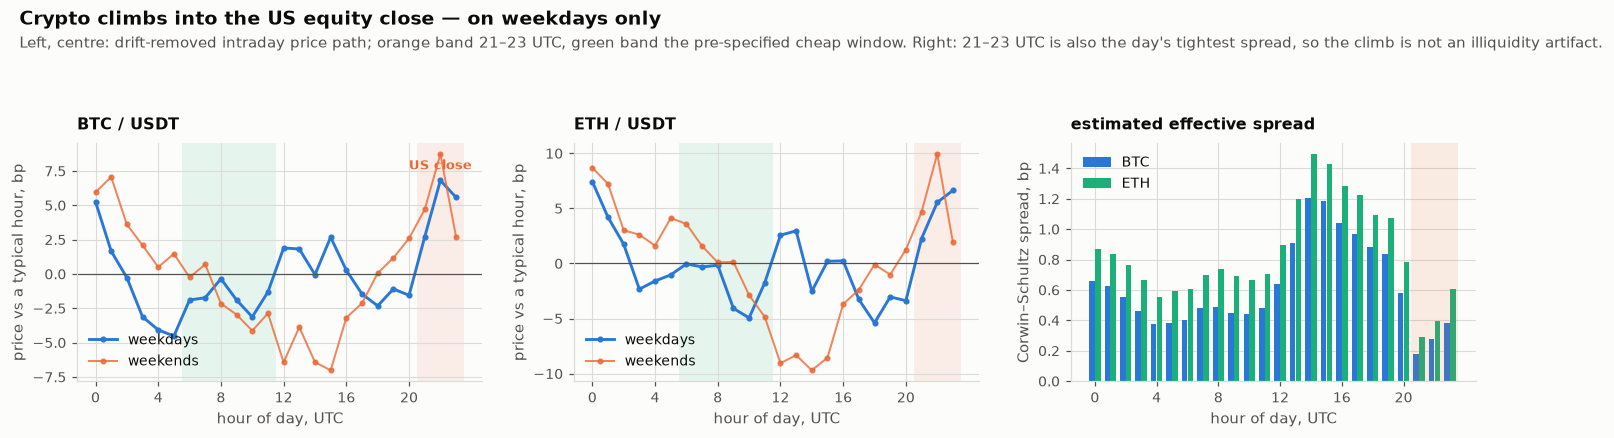

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
for ax, s in zip(axes[:2], HYP):
    h = H[s]
    for lbl, m, c in (("weekdays", h.index.dayofweek < 5, C1),
                      ("weekends", h.index.dayofweek >= 5, C2)):
        sub = h[m]
        cum = (sub.groupby(sub.index.hour).mean() - sub.mean()).cumsum()
        ax.plot(cum.index, cum.values - cum.mean(), color=c, label=lbl, marker="o", ms=3,
                lw=1.9 if lbl == "weekdays" else 1.3, alpha=1.0 if lbl == "weekdays" else 0.8)
    ax.axvspan(DEAR[0]-0.5, DEAR[-1]+0.5, color=C2, alpha=0.10, lw=0)
    ax.axvspan(CHEAP[0]-0.5, CHEAP[-1]+0.5, color=C3, alpha=0.10, lw=0)
    ax.axhline(0, color=INK_2, lw=0.8)
    ax.set_title(s.replace("USDT", " / USDT"))
    ax.set_xlabel("hour of day, UTC"); ax.set_ylabel("price vs a typical hour, bp")
    ax.set_xticks(range(0, 24, 4)); ax.legend(loc="lower left")
axes[0].annotate("US close", xy=(22, axes[0].get_ylim()[1]*0.80), fontsize=8.5,
                 color=C2, ha="center", weight="bold")
ax = axes[2]
ax.set_axisbelow(True)
w = 0.36
for i, s in enumerate(HYP):
    ax.bar(np.arange(24) + (i-0.5)*w*1.05, S_BY_HOUR[s].values, width=w,
           color=[C1, C3][i], label=s.replace("USDT", ""))
ax.axvspan(DEAR[0]-0.5, DEAR[-1]+0.5, color=C2, alpha=0.12, lw=0)
ax.set_title("estimated effective spread")
ax.set_xlabel("hour of day, UTC"); ax.set_ylabel("Corwin–Schultz spread, bp")
ax.set_xticks(range(0, 24, 4)); ax.legend()
figure_titles(fig, "Crypto climbs into the US equity close — on weekdays only",
              "Left, centre: drift-removed intraday price path; orange band 21–23 UTC, green band the "
              "pre-specified cheap window. Right: 21–23 UTC is also the day's tightest spread, so the climb "
              "is not an illiquidity artifact.",
              top=0.86)
plt.show()

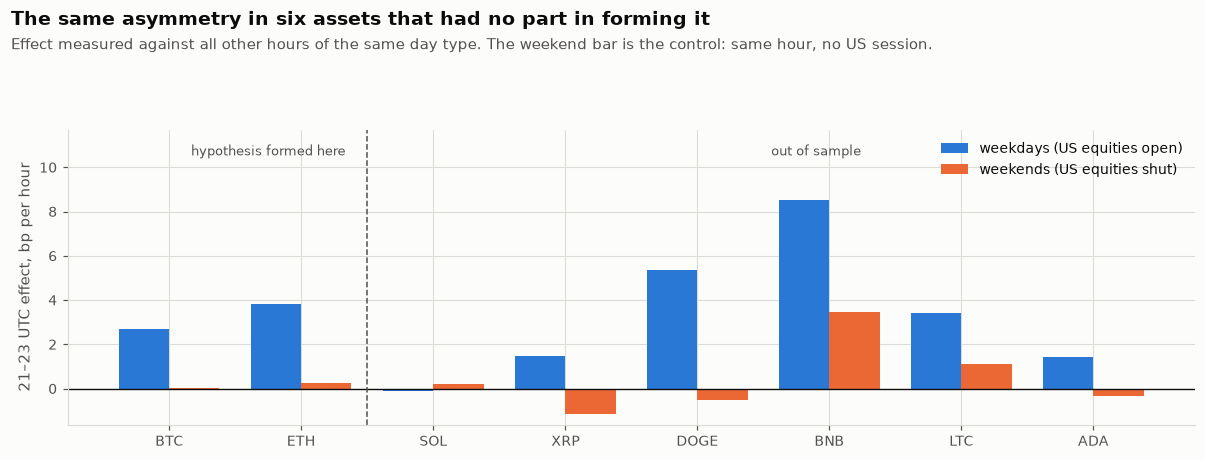

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.set_axisbelow(True)
allr = pd.concat([E3W.assign(asset=E3W.asset.str.replace("USDT", "")), E4T], ignore_index=True)
order = [s.replace("USDT", "") for s in HYP + OOS]
piv = allr.pivot_table(index="asset", columns="days", values="effect_bp_hr").reindex(order)
x = np.arange(len(piv))
ax.bar(x-0.19, piv["weekday"], 0.38, color=C1, label="weekdays (US equities open)")
ax.bar(x+0.19, piv["weekend"], 0.38, color=C2, label="weekends (US equities shut)")
ax.axhline(0, color=INK, lw=0.9)
ax.axvline(1.5, color=INK_2, lw=1.0, ls="--")
ax.set_ylim(top=ax.get_ylim()[1]*1.30)
ax.text(0.75, ax.get_ylim()[1]*0.90, "hypothesis formed here", ha="center", fontsize=8.5, color=INK_2)
ax.text(4.9, ax.get_ylim()[1]*0.90, "out of sample", ha="center", fontsize=8.5, color=INK_2)
ax.set_xticks(x); ax.set_xticklabels(piv.index)
ax.set_ylabel("21–23 UTC effect, bp per hour"); ax.legend(loc="upper right")
figure_titles(fig, "The same asymmetry in six assets that had no part in forming it",
              "Effect measured against all other hours of the same day type. The weekend bar is the control: "
              "same hour, no US session.", top=0.84)
plt.show()

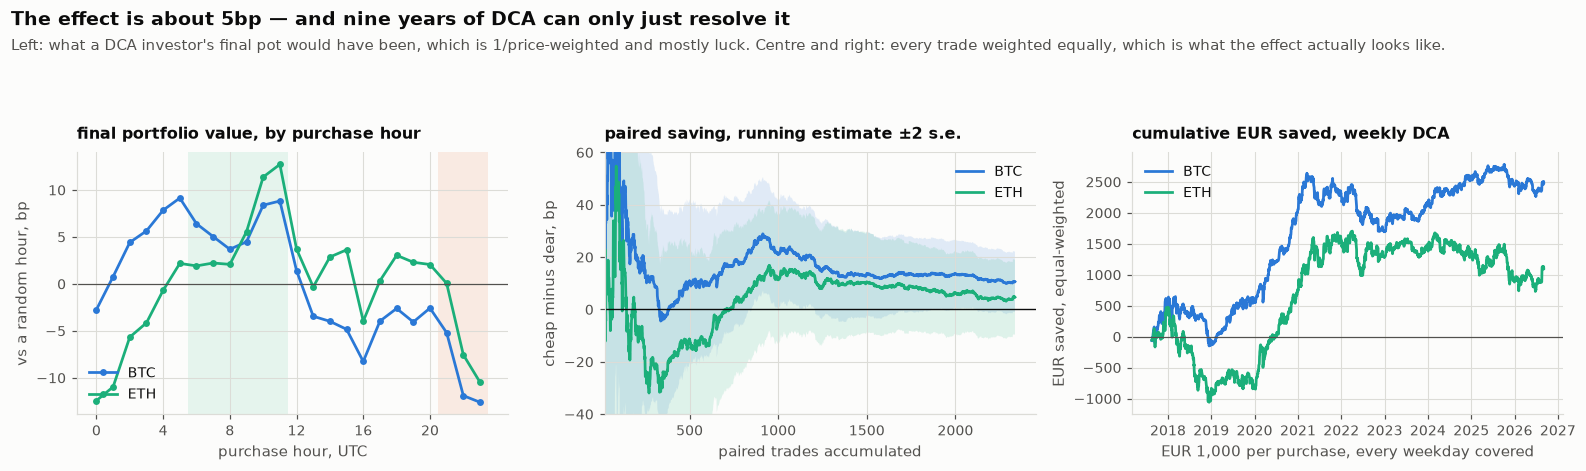

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))

ax = axes[0]
for i, s in enumerate(HYP):
    u = pd.Series({h: np.mean([(TRADE/EFF[s].loc[SCHED[(s, "weekly", ph)], h]).sum()
                               for ph in PHASES]) for h in range(24)})
    ax.plot(u.index, (u/u.mean()-1)*1e4, marker="o", ms=3.5, color=[C1, C3][i],
            label=s.replace("USDT", ""))
ax.axvspan(DEAR[0]-0.5, DEAR[-1]+0.5, color=C2, alpha=0.12, lw=0)
ax.axvspan(CHEAP[0]-0.5, CHEAP[-1]+0.5, color=C3, alpha=0.10, lw=0)
ax.axhline(0, color=INK_2, lw=0.8)
ax.set_title("final portfolio value, by purchase hour")
ax.set_xlabel("purchase hour, UTC"); ax.set_ylabel("vs a random hour, bp")
ax.set_xticks(range(0, 24, 4)); ax.legend(loc="lower left")

ax = axes[1]
for i, s in enumerate(HYP):
    d = PAIRED[(s, "weekly")]
    run = d.expanding().mean()
    se = d.expanding().std()/np.sqrt(np.arange(1, len(d)+1))
    ax.plot(np.arange(1, len(d)+1), run.values, color=[C1, C3][i], label=s.replace("USDT", ""))
    ax.fill_between(np.arange(1, len(d)+1), (run-2*se).values, (run+2*se).values,
                    color=[C1, C3][i], alpha=0.13, lw=0)
ax.axhline(0, color=INK, lw=0.9)
ax.set_ylim(-40, 60); ax.set_xlim(20, None)
ax.set_title("paired saving, running estimate ±2 s.e.")
ax.set_xlabel("paired trades accumulated"); ax.set_ylabel("cheap minus dear, bp")
ax.legend(loc="upper right")

ax = axes[2]
for i, s in enumerate(HYP):
    d = PAIRED[(s, "weekly")]
    ax.plot(d.index, (d/1e4*TRADE).cumsum().values, color=[C1, C3][i], label=s.replace("USDT", ""))
ax.axhline(0, color=INK_2, lw=0.8)
ax.set_title("cumulative EUR saved, weekly DCA")
ax.set_xlabel("EUR 1,000 per purchase, every weekday covered")
ax.set_ylabel("EUR saved, equal-weighted")
ax.legend(loc="upper left")
figure_titles(fig, f"The effect is about {POOL:.0f}bp — and nine years of DCA can only just resolve it",
              "Left: what a DCA investor's final pot would have been, which is 1/price-weighted and mostly luck. "
              "Centre and right: every trade weighted equally, which is what the effect actually looks like.",
              top=0.85)
plt.show()

---
# VERDICT

In [15]:
W = 82
CRIT = [("E1", "Statistically present (ANOVA across 24 hours)", E1),
        ("E2", "Not a microstructure artifact (survives on VWAP)", E2),
        ("E3", "Mechanism-consistent (absent at weekends)", E3),
        ("E4", "Holds on six unseen assets", E4),
        ("E5", "Usable net of spread, fees and drift", E5)]
npass = sum(bool(c[2]) for c in CRIT)
wd_eff = E3W.loc[E3W.days == "weekday", "effect_bp_hr"].mean()
print("=" * W)
print("GO, WITH A CEILING — THE EDGE IS REAL AND IT IS TINY".center(W))
print(f"about {POOL:.0f} basis points, or EUR {POOL/1e4*TRADE:.2f} on a EUR 1,000 purchase".center(W))
print("=" * W + "\n")
for cid, desc, ok in CRIT:
    print(f"  {cid}  [{'PASS' if ok else 'FAIL'}]  {desc}")
print(f"\n  {npass}/5 criteria met.\n")
print(f"""WHAT IT IS
{'-'*W}
  Crypto prices drift upward into and just after the US equity close, 21:00-23:00
  UTC, by {wd_eff:.1f}bp per hour on weekdays. The pattern is absent at weekends, when US
  equity markets are shut — same hour, same 24/7 market, no US session. It shows
  up in six assets that had no part in forming the hypothesis. It survives on
  VWAP, so it is not bid-ask bounce. And that window carries the tightest spreads
  of the day, which is what you would expect if institutional flow is what
  arrives there.

  The story: US end-of-day and close-auction flow spills into crypto. The risk
  that gets put on at the equity close is not only equity risk. It is NOT "US
  traders buy all day" — the US session as a whole is flat, only the close window
  carries, and that specificity is what made the weekend test worth running.

  Is it known? Yes, in the general form. Equity markets have a documented
  end-of-day return pattern, and cross-market spillover from the US close into
  Asian and European hours is old literature. What is not standard is the size in
  crypto or whether a retail buyer can use it, which is what this notebook prices.

WHAT IT IS NOT
{'-'*W}
  Not a strategy. Capturing it directly needs a round trip every weekday: ~{wd_eff*3:.0f}bp
  of gross effect against ~30bp of round-trip cost, so {-252*30/100 + wd_eff*3*252/100:+.0f}%/yr net. Notebook
  7's arithmetic disposes of it, as it disposed of everything at that frequency.

  Nothing here rescues the strategies notebooks 1-7 rejected, and nothing here
  says whether crypto is worth owning. It is an execution result, not a return.

HOW TO USE IT
{'-'*W}
  On purchases you were making anyway — zero extra trades, so the cost arithmetic
  never bites. The rule is one line:

      DO NOT BUY BETWEEN 21:00 AND 00:00 UTC ON A WEEKDAY.

  Two ways of sizing what obeying it is worth, and they agree:
      vs buying at an hour picked at random   {DR.dear_vs_typical_bp.mean():.1f}bp  (drift-removed profile)
      vs buying in the dear window            {POOL:.1f}bp  (paired backtest, net of costs)
  Avoiding the peak is the reliable half. Actively seeking the European-morning
  trough adds little on top — the peak is sharp and consistent, the trough is
  broad and noisy, and cheap-vs-random came out {BTT.cheap_vs_naive_bp.min():+.0f} to {BTT.cheap_vs_naive_bp.max():+.0f}bp.

WHAT CAPITAL MAKES IT WORTH THE BOTHER
{'-'*W}
  {POOL:.1f}bp is scale-free, so the honest answer is "none — it is about effort, not
  capital".
      per EUR 1,000 purchase                 EUR {POOL/1e4*TRADE:.2f}
      monthly DCA of EUR 1,000, one year     EUR {POOL/1e4*TRADE*12:.0f}
      monthly DCA of EUR 1,000, ten years    EUR {POOL/1e4*TRADE*120:.0f}
  Obeying it costs nothing — you pick a different hour in the same app — so it is
  worth doing at any size, including EUR 100. It is not worth building anything
  for, not worth an alarm clock, and above all not worth one extra trade at any
  size: a single extra round trip at 30bp destroys {30/POOL:.0f} purchases' worth of it.

  There is no capital level at which this becomes interesting on its own. At EUR
  100,000 a month it is EUR {POOL/1e4*100000:.0f} a month, and at that size you have larger
  problems (notebook 4 put total strategy capacity at ~USD 250k).

HONEST SIZING
{'-'*W}
  I want to be explicit about how this number shrank, because the shrinking is
  the useful part:

      first pass, best hour vs worst hour     up to 419bp   biased: max of 24 noisy means
      pre-specified windows, Monday-only DCA      31bp   phase artifact, 472/473 Mondays
      phase-averaged final portfolio value      12-26bp   1/price-weighted, mostly luck
      phase-averaged, paired, drift removed        {POOL:.1f}bp   what is actually there

  Each step removed a way of flattering the result, and each one cost an order of
  magnitude. The {POOL:.1f}bp survives an independent check: the drift-removed hourly
  profile, computed from 3.3M bars with no backtest at all, says {DR.shape_part_bp.mean():.1f}bp.

  For scale, {POOL:.1f}bp is about a fifth of one side of a Kraken or Bitvavo retail fee.
  Anyone reading this as a reason to trade more has read it backwards. The finding
  across eight notebooks is that the structure in this market is smaller than the
  cost of acting on it; this is the one example that lands on the right side of
  the line, and only because acting on it is free.

CAVEATS I WILL NOT BURY
{'-'*W}
  * The six out-of-sample assets co-move with BTC, so they are a weak replication
    of one market-wide effect, not six independent confirmations. Two of the six
    (SOL, XRP) show nothing on their own.
  * The daylight-saving test — the sharpest confirmation available, since a real
    US-close effect must shift one hour twice a year — came back INCONCLUSIVE.
    The sample cannot resolve one hour. E3 rests on the weekend test alone.
  * The full 24-hour profile does not replicate across sample halves (Spearman
    +0.08 BTC, -0.01 ETH). Only the narrow, mechanism-backed window carries; any
    claim about other hours would be overfitting.
  * The per-trade saving is barely two standard errors even at {int(WK.n_trades.mean()):,} paired
    trades, and not significant for ETH alone. The evidence for the effect is
    the 3.3M hourly bars in E1-E4, not the backtest.
  * The aggregate DCA table in section 6 spans {BTT.cheap_vs_dear_bp.min():+.0f} to {BTT.cheap_vs_dear_bp.max():+.0f}bp across four schedules
    on identical dates. Accumulated units are 1/price-weighted and dominated by
    2017-18 trades, so "final portfolio value" simply cannot measure something
    this small — which is why the headline comes from the paired estimator.
  * Corwin-Schultz understates true spreads. The between-hour comparison is
    robust to that; the absolute level of the DCA outcome is not.
  * Binance USDT is not a EUR retail account. Venue fees, EUR conversion and tax
    each dwarf EUR {POOL/1e4*TRADE:.2f} of timing. Choosing a cheaper exchange is worth
    more than every basis point in this notebook, several times over.""")
print("=" * W)

               GO, WITH A CEILING — THE EDGE IS REAL AND IT IS TINY               
            about 5 basis points, or EUR 0.48 on a EUR 1,000 purchase             

  E1  [PASS]  Statistically present (ANOVA across 24 hours)
  E2  [PASS]  Not a microstructure artifact (survives on VWAP)
  E3  [PASS]  Mechanism-consistent (absent at weekends)
  E4  [PASS]  Holds on six unseen assets
  E5  [PASS]  Usable net of spread, fees and drift

  5/5 criteria met.

WHAT IT IS
----------------------------------------------------------------------------------
  Crypto prices drift upward into and just after the US equity close, 21:00-23:00
  UTC, by 3.3bp per hour on weekdays. The pattern is absent at weekends, when US
  equity markets are shut — same hour, same 24/7 market, no US session. It shows
  up in six assets that had no part in forming the hypothesis. It survives on
  VWAP, so it is not bid-ask bounce. And that window carries the tightest spreads
  of the day, which is what you would expe